In [1]:
import pandas as pd
import os

# Define the file path using a raw string to handle Windows backslashes safely
# Updated to point to the new mird_benchmark_test output directory if needed
file_path = r"/home/matias/Documents/Tesis/Vision-Aided-Beamformer/data_analysis/avance2/Data/Exp_A.parquet"

# Define a mapping dictionary to rename processors for cleaner plotting
# You can easily edit the string values on the right side of the colon
PROCESSOR_MAP = {
    "DS": "DS",
    "DTLN-MVDR": "DTLN-MVDR",
    "DTLN-RTF-MVDR": "DTLN-MVDR-SV"
}

# Verify if the file exists before attempting to load it
if os.path.exists(file_path):
    # Load the Parquet file into a Pandas DataFrame
    df_metrics = pd.read_parquet(file_path)

    # Apply the processor mapping to the 'processor' column right after loading
    if 'processor' in df_metrics.columns:
        df_metrics['processor'] = df_metrics['processor'].replace(PROCESSOR_MAP)

    # Filter out all rows where isir_db is 0.0 (anechoic conditions) and reset the index
    df_metrics = df_metrics[df_metrics['isir_db'] > 0.0].reset_index(drop=True)

    # Identify and keep only metadata columns and metrics evaluated with the 'early' reference
    suffixes_to_drop = ('_anechoic', '_reverberant')
    cols_to_keep = [col for col in df_metrics.columns if not col.endswith(suffixes_to_drop)]
    df_metrics = df_metrics[cols_to_keep]

    # Strip the '_early' suffix from the column names for cleaner plotting later
    df_metrics.columns = [col.replace('_early', '') if col.endswith('_early') else col for col in df_metrics.columns]

    print(f"Dataset successfully loaded, filtered, and processors mapped! Shape: {df_metrics.shape}\n")

    # Display the first few rows to confirm data integrity
    display(df_metrics.head())

else:
    print(f"Error: File not found at the specified path:\n{file_path}")
    print("Please check your current working directory using 'import os; print(os.getcwd())'.")

Dataset successfully loaded, filtered, and processors mapped! Shape: (72, 92)



,processor,rt60,M,N_interferences,mismatch_pos,isir_db,mismatch_gain,mismatch_phase,use_wpe,error_angle_deg,...,Delta_dtln_post_SAR,Delta_tot_pipeline_SAR,Delta_tot_SINR,Delta_wpe_SINR,Delta_bf_SINR,dtln_alone_SINR,dtln_post_SINR,Delta_dtln_alone_SINR,Delta_dtln_post_SINR,Delta_tot_pipeline_SINR
0,DS,0.16,8,2,0.0,5,0,0,False,0.0,...,-30.398181,-44.260812,-0.229760,0.0,-0.229760,21.576740,20.641584,15.272219,14.566823,14.337063
1,DTLN-MVDR,0.16,8,2,0.0,5,0,0,False,0.0,...,-3.012688,-42.110146,15.413222,0.0,15.413222,21.576740,22.181986,15.272219,0.464242,15.877464
2,DTLN-MVDR-SV,0.16,8,2,0.0,5,0,0,False,0.0,...,-0.824550,-47.825059,5.243688,0.0,5.243688,21.576740,22.075583,15.272219,10.527374,15.771062
3,DS,0.16,8,2,0.0,10,0,0,False,0.0,...,-28.578312,-41.902191,-0.229949,0.0,-0.229949,23.354024,23.263677,12.050343,12.189946,11.959996
4,DTLN-MVDR,0.16,8,2,0.0,10,0,0,False,0.0,...,-5.020249,-39.452789,14.984439,0.0,14.984439,23.354024,26.371592,12.050343,0.083472,15.067911


Valores unicos de isir_db en los datos: [ 5 10]


/tmp/ipykernel_95402/51024140.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_95402/51024140.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_95402/51024140.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_95402/51024140.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


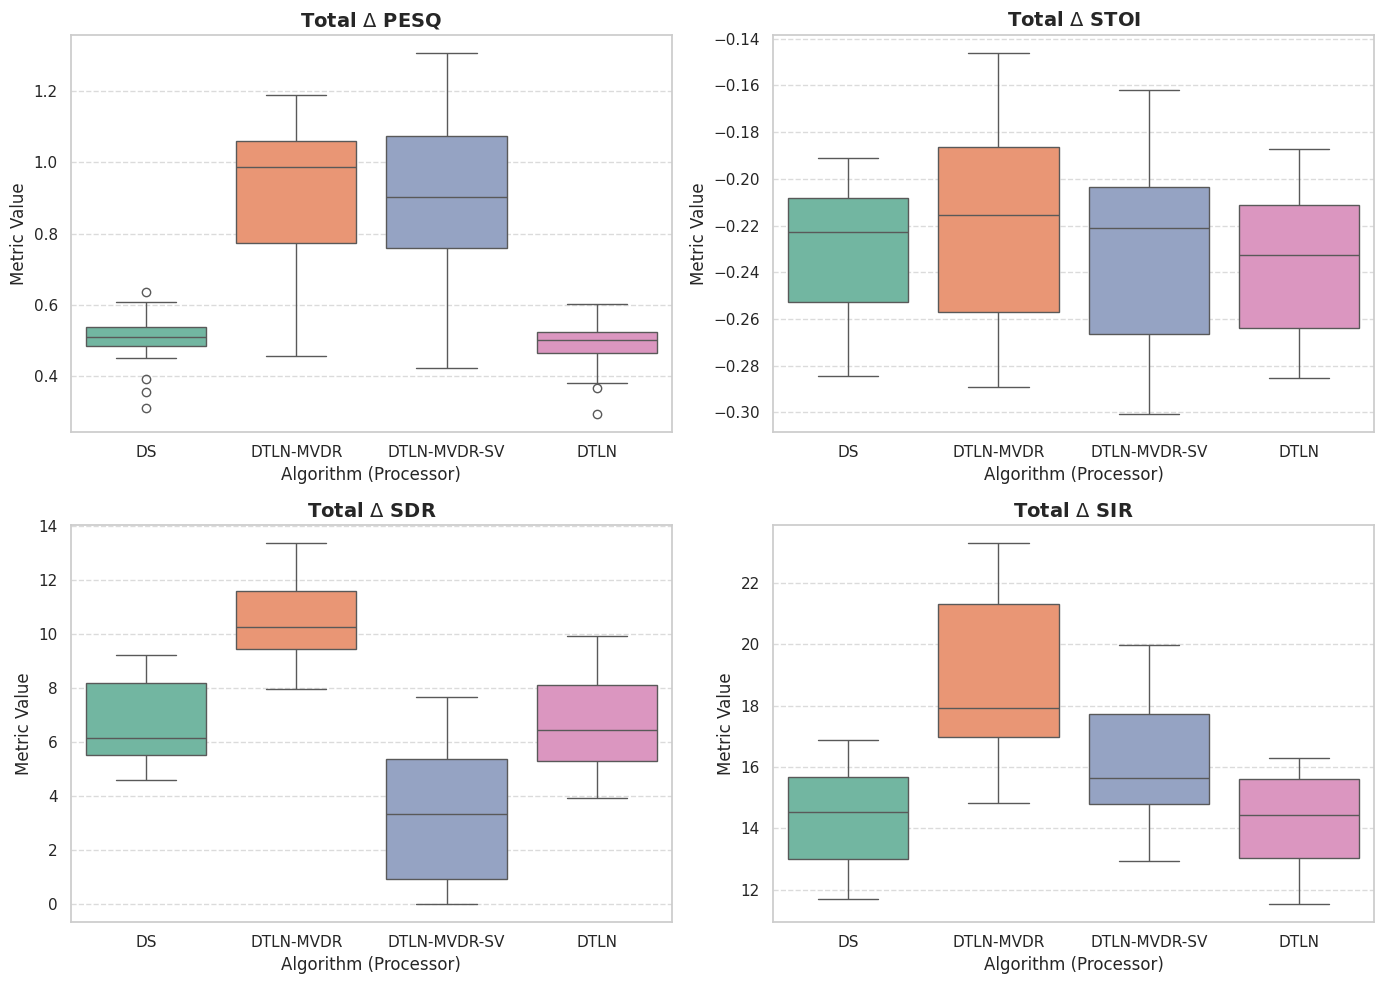

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer + DTLN results
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        col_name = f'Delta_tot_pipeline_{metric}'
        if col_name in df_proc.columns:
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract DTLN Alone results
# DTLN alone is computed per acoustic scene, not per processor.
# To avoid duplicating the exact same DTLN alone values for every processor
# evaluated in the same scene, we just grab them from the first processor's rows.
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            for val in df_dtln_alone[col_name].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot with Algorithms on the X-axis and metric values on the Y-axis
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette='Set2'
    )

    # Format titles and labels for clarity
    axes[i].set_title(f'Total $\Delta$ {metric}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Metric Value', fontsize=12)
    axes[i].set_xlabel('Algorithm (Processor)', fontsize=12)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Display the plot
plt.show()

In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define the root directory to save all generated figures for the thesis
FIGURES_DIR = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Desarrollo/Algoritmos"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Define the Okabe-Ito color palette for colorblind accessibility
# Colors: Orange, Sky Blue, Bluish Green, Yellow, Blue, Vermilion, Reddish Purple, Black
OKABE_ITO_PALETTE = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#000000"
]

def set_thesis_plot_style():
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Integrates Okabe-Ito colors and sizes appropriate for an A4 LaTeX document.
    """
    # Set the general Seaborn style and apply the new palette
    sns.set_theme(style="whitegrid", context="paper")
    sns.set_palette(sns.color_palette(OKABE_ITO_PALETTE))

    # Configure Matplotlib parameters
    plt.rcParams.update({
        # Typography: Sans-serif is recommended for charts for better readability
        # If you want to strictly match LaTeX text, change "sans-serif" to "serif"
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

        # Font sizes coordinated with an 11pt main text in LaTeX
        "font.size": 11,                 # Base font size (matches document)
        "axes.titlesize": 11,            # Subplot title size
        "axes.labelsize": 10,            # Axis labels slightly smaller than main text
        "xtick.labelsize": 9,            # Tick labels (max 2 points smaller)
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,

        # Apply Okabe-Ito to base Matplotlib cycle (for non-Seaborn plots)
        "axes.prop_cycle": plt.cycler('color', OKABE_ITO_PALETTE),

        # Dimensions matching A4 paper with standard 2.5 cm margins
        # Text width is ~160mm (6.3 inches). Height uses the golden ratio (~3.89 inches).
        "figure.figsize": (6.3, 3.89),

        # High resolution outputs
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",         # Removes unnecessary white space around edges

        # Line and marker weights
        "lines.linewidth": 1.5,          # Slightly thicker for better visibility
        "lines.markersize": 5
    })

/tmp/ipykernel_95402/1559241521.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_95402/1559241521.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_95402/1559241521.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_95402/1559241521.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


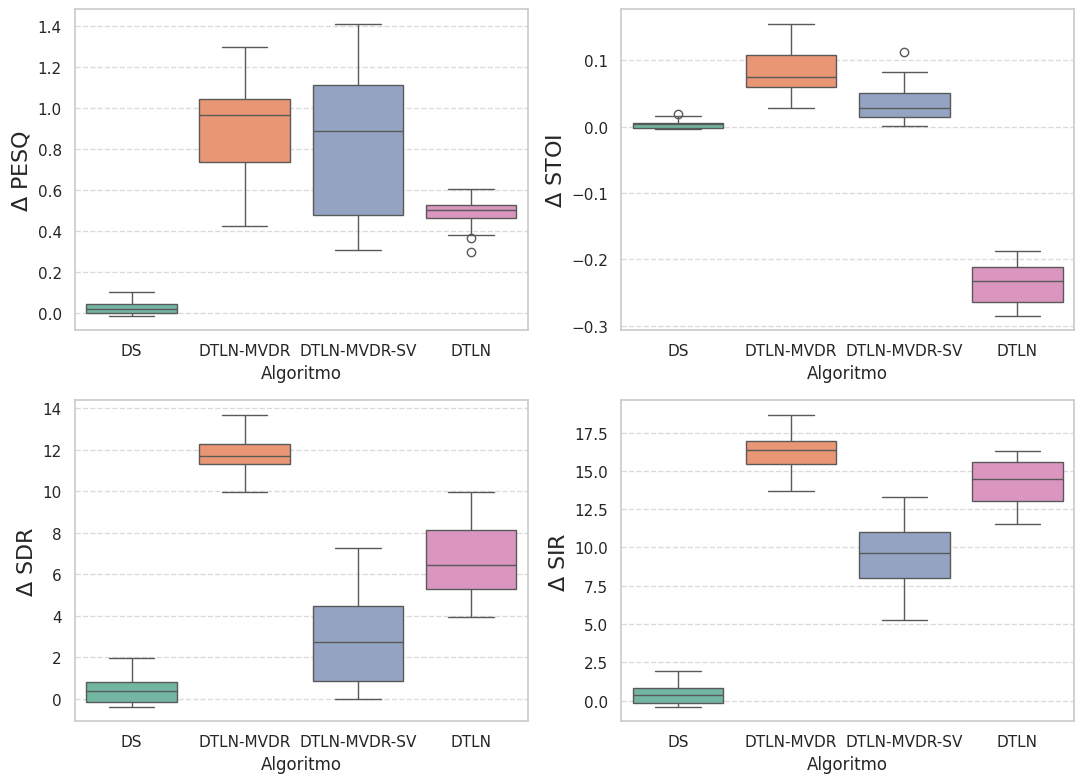

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer-only results (No DTLN post-processing)
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        # We use 'Delta_tot_' to get the performance of the Beamformer alone compared to the baseline
        col_name = f'Delta_tot_{metric}'
        if col_name in df_proc.columns:
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract DTLN Alone results
# We extract this only from the first processor's rows to avoid duplicating
# the same DTLN values for the same acoustic scene.
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            for val in df_dtln_alone[col_name].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot with Algorithms on the X-axis and metric values on the Y-axis
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette='Set2'
    )

    # Format titles and labels for clarity

    # Update the Y-axis to dynamically show the specific metric name
    axes[i].set_ylabel(f'$\Delta$ {metric}', fontsize=16)

    # Update the X-axis label to Spanish to match the plot title
    axes[i].set_xlabel('Algoritmo', fontsize=12)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Save the figure as a PDF file
# You can change this path to point exactly where you need it
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/boxplot_resultados_generales__.pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Display the plot
plt.show()

/tmp/ipykernel_95402/3393607904.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_95402/3393607904.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_95402/3393607904.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_95402/3393607904.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


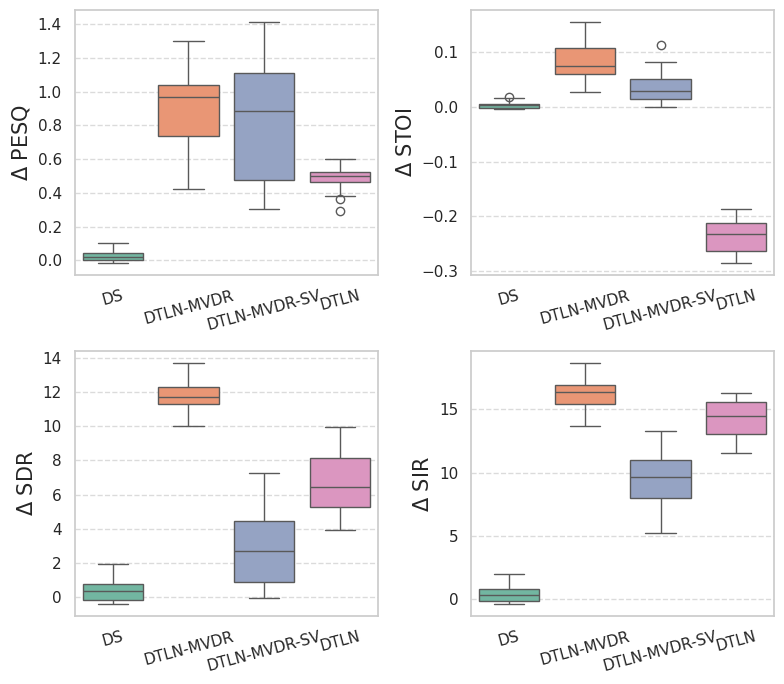

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer-only results (No DTLN post-processing)
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        # We use 'Delta_tot_' to get the performance of the Beamformer alone compared to the baseline
        col_name = f'Delta_tot_{metric}'
        if col_name in df_proc.columns:
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract DTLN Alone results
# We extract this only from the first processor's rows to avoid duplicating
# the same DTLN values for the same acoustic scene.
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            for val in df_dtln_alone[col_name].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot with Algorithms on the X-axis and metric values on the Y-axis
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette='Set2'
    )

    # Format titles and labels for clarity

    # Update the Y-axis to dynamically show the specific metric name
    axes[i].set_ylabel(f'$\Delta$ {metric}', fontsize=15)

    # Update the X-axis label to Spanish to match the plot title
    axes[i].set_xlabel('', fontsize=12)

    # Rotate the X-axis labels slightly and align them to the right for better horizontal spacing
    plt.setp(axes[i].get_xticklabels(), rotation=15, ha='center')

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Save the figure as a PDF file
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/boxplot_resultados_generales.pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight')

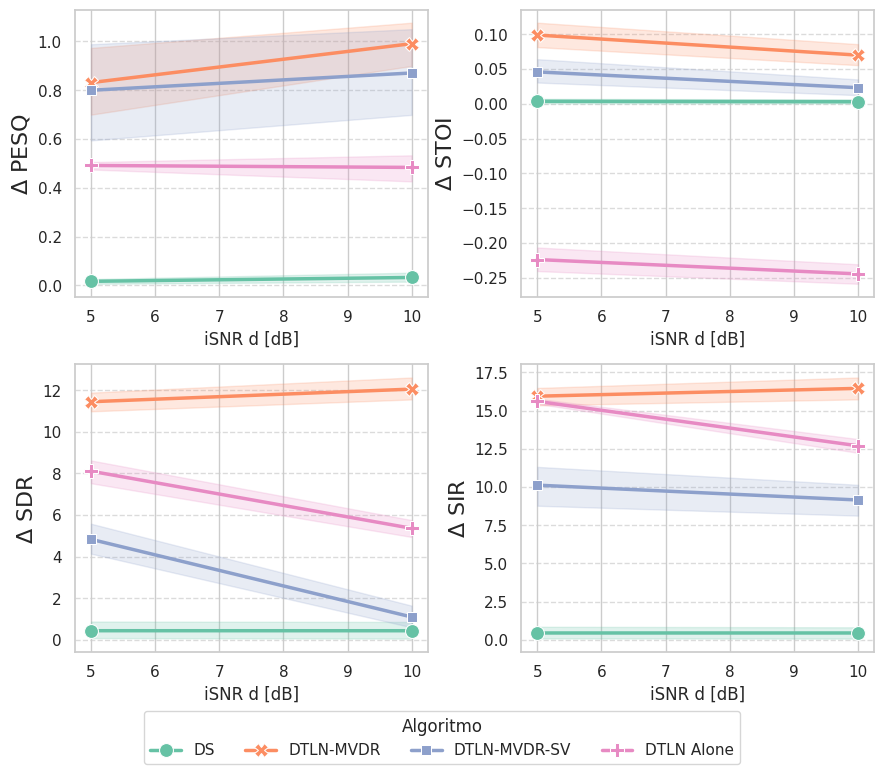

In [8]:
# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer-only results (No DTLN post-processing)
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        col_name = f'Delta_tot_{metric}'
        if col_name in df_proc.columns:
            df_valid = df_proc.dropna(subset=[col_name])
            for idx, row in df_valid.iterrows():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': row[col_name],
                    'isir_db': row['isir_db'] # Extract isir_db instead of interferences
                })

# 2. Extract DTLN Alone results
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            df_valid = df_dtln_alone.dropna(subset=[col_name])
            for idx, row in df_valid.iterrows():
                plot_data.append({
                    'Algorithm': 'DTLN Alone',
                    'Metric': metric,
                    'Value': row[col_name],
                    'isir_db': row['isir_db'] # Extract isir_db instead of interferences
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
# Increased bottom margin (using subplots_adjust later) to fit the legend
fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))
axes = axes.flatten()

for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the lineplot with isir_db on the X-axis
    sns.lineplot(
        data=df_subset,
        x='isir_db',
        y='Value',
        hue='Algorithm',
        style='Algorithm',
        markers=True,
        dashes=False,
        linewidth=2.5,  # Set the thickness of the lines here
        ax=axes[i],
        palette='Set2',
        markersize=10,
    )

    # Format titles and labels for clarity
    axes[i].set_ylabel(f'$\Delta$ {metric}', fontsize=16)

    # Update X-axis label to reflect the new variable
    axes[i].set_xlabel('iSNR d [dB]', fontsize=12)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# --- CORRECTED LEGEND LOGIC ---

# 1. Retrieve handles and labels from the first subplot (which successfully generated a legend)
handles, labels = axes[0].get_legend_handles_labels()

# 2. Remove the individual legends from ALL subplots to keep the grid clean
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# 3. Add the global legend to the figure at the bottom
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(df_plot['Algorithm'].unique()),
    bbox_to_anchor=(0.5, -0.04), # Anchor it exactly at the bottom middle
    title="Algoritmo"
)

# Adjust the layout so plots do not overlap and leave space at the bottom for the legend
plt.tight_layout()

# Adjust bottom margin; 0.12 leaves enough space for a single-row legend
plt.subplots_adjust(bottom=0.12)

# Save the figure as a PDF file with a new name reflecting the isir_db analysis
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/lineplot_resultados_generales_isir_db.pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Display the plot
plt.show()

Valores unicos de isir_db en los datos: [ 5 10]


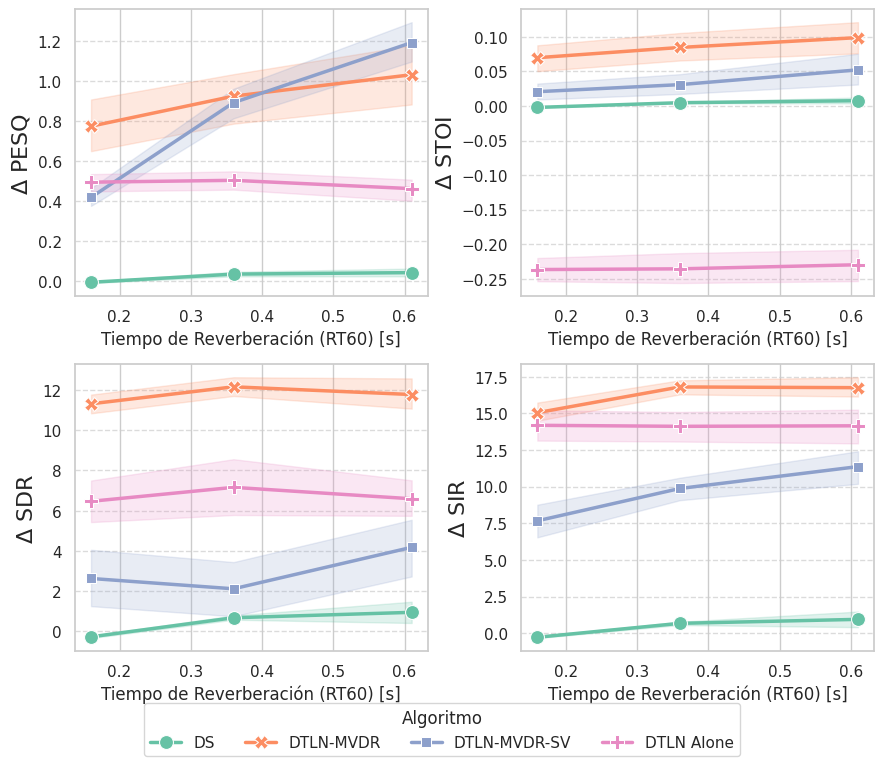

In [9]:


# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer-only results (No DTLN post-processing)
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        col_name = f'Delta_tot_{metric}'
        if col_name in df_proc.columns:
            df_valid = df_proc.dropna(subset=[col_name])
            for idx, row in df_valid.iterrows():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': row[col_name],
                    'RT60': row['rt60'] # Extract RT60 instead of interferences
                })

# 2. Extract DTLN Alone results
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            df_valid = df_dtln_alone.dropna(subset=[col_name])
            for idx, row in df_valid.iterrows():
                plot_data.append({
                    'Algorithm': 'DTLN Alone',
                    'Metric': metric,
                    'Value': row[col_name],
                    'RT60': row['rt60'] # Extract RT60 instead of interferences
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
# Increased bottom margin (using subplots_adjust later) to fit the legend
fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))
axes = axes.flatten()

for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the lineplot with RT60 on the X-axis
    sns.lineplot(
        data=df_subset,
        x='RT60',
        y='Value',
        hue='Algorithm',
        style='Algorithm',
        markers=True,
        dashes=False,
        linewidth=2.5,  # Set the thickness of the lines here
        ax=axes[i],
        palette='Set2',
        markersize=10,
    )

    # Format titles and labels for clarity
    axes[i].set_ylabel(f'$\Delta$ {metric}', fontsize=16)

    # Update X-axis label to reflect the new variable
    axes[i].set_xlabel('Tiempo de Reverberación (RT60) [s]', fontsize=12)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# --- CORRECTED LEGEND LOGIC ---

# 1. Retrieve handles and labels from the first subplot (which successfully generated a legend)
handles, labels = axes[0].get_legend_handles_labels()

# 2. Remove the individual legends from ALL subplots to keep the grid clean
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# 3. Add the global legend to the figure at the bottom
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(df_plot['Algorithm'].unique()),
    bbox_to_anchor=(0.5, -0.03), # Anchor it exactly at the bottom middle
    title="Algoritmo"
)

# Adjust the layout so plots do not overlap and leave space at the bottom for the legend
plt.tight_layout()

# Adjust bottom margin; 0.12 leaves enough space for a single-row legend
plt.subplots_adjust(bottom=0.12)

# Save the figure as a PDF file with a new name reflecting the RT60 analysis
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/lineplot_resultados_generales_rt60.pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Display the plot
plt.show()